In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import seaborn as sns
import numpy as np

from scipy.interpolate import interp1d
from scipy.integrate import simpson

def convolve_with_throughput(wavelength, spectrum, thr_wave, thr_val):
   interp_thr = interp1d(thr_wave, thr_val, bounds_error=False, fill_value=0.0)
   T = interp_thr(wavelength)
   numerator = simpson(spectrum * T, wavelength)
   denominator = simpson(T, wavelength)
   if denominator == 0:
       return np.nan
   return numerator / denominator

In [2]:
df_rad = pd.read_csv('psg_rad-EarthPrototype.txt', comment='#', delim_whitespace=True).dropna()
df_tel = pd.read_csv('psg_tel-EarthPrototype.txt', comment='#', delim_whitespace=True).dropna()
df_trn = pd.read_csv('psg_trn-EarthPrototype.txt', comment='#', delim_whitespace=True).dropna()
df_rad.columns = ['Wave/freq', 'Total', 'Stellar', 'Earth-like-Prototype', 'Transit']
df_tel.columns = ['Wave/freq', 'Telluric']
df_trn.columns = ['Wave/freq', 'Transmittance']

      Wave/freq     Total  Stellar  Earth-like-Prototype   Transit
0      0.500100  0.000509      1.0              0.000075  0.000075
1      0.500200  0.000382      1.0              0.000075  0.000075
2      0.500300  0.000284      1.0              0.000075  0.000075
3      0.500400  0.000212      1.0              0.000075  0.000075
4      0.500500  0.000162      1.0              0.000075  0.000075
...         ...       ...      ...                   ...       ...
3705   1.049148 -0.000261      1.0              0.000084  0.000084
3706   1.049358 -0.000438      1.0              0.000084  0.000084
3707   1.049568 -0.000678      1.0              0.000084  0.000084
3708   1.049778 -0.000991      1.0              0.000084  0.000084
3709   1.049988 -0.001384      1.0              0.000084  0.000084

[3710 rows x 5 columns]


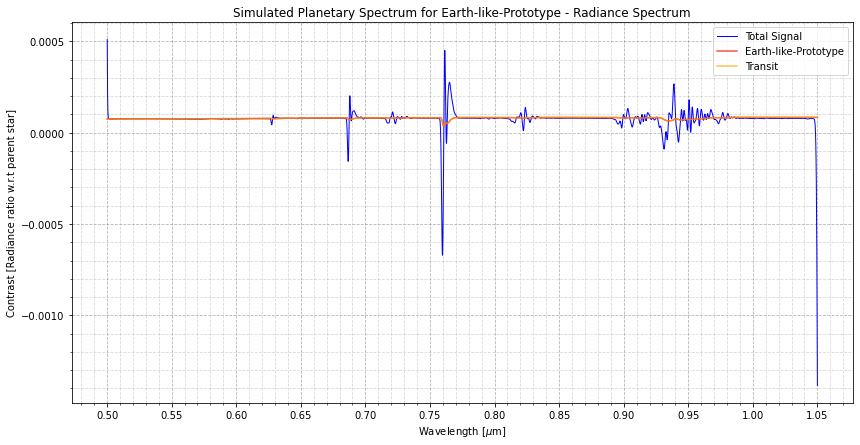

In [3]:
print(df_rad)

plt.figure(figsize=(14, 7))
plt.plot(df_rad['Wave/freq'], df_rad['Total'], label='Total Signal', color='blue', linewidth=1)
plt.plot(df_rad['Wave/freq'], df_rad['Earth-like-Prototype'],
         label='Earth-like-Prototype', 
         color='red',
         linewidth=1.5,
         alpha=0.7)
plt.plot(df_rad['Wave/freq'], df_rad['Transit'],
         label='Transit', 
         color='orange', 
         alpha=0.7)

plt.xlabel('Wavelength [$\mu$m]')
#plt.xscale('log')
plt.ylabel('Contrast [Radiance ratio w.r.t parent star]') 
plt.title('Simulated Planetary Spectrum for Earth-like-Prototype - Radiance Spectrum')
plt.legend()

ax = plt.gca() 

ax.xaxis.set_major_locator(MultipleLocator(0.05))
ax.yaxis.set_major_locator(MultipleLocator(0.0005))

ax.xaxis.set_minor_locator(MultipleLocator(0.01))
ax.yaxis.set_minor_locator(MultipleLocator(0.0001))


plt.grid(visible=True, 
         which='major', 
         color='grey', 
         linestyle='--', 
         alpha=0.6)
plt.grid(visible=True, 
         which='minor', 
         color='grey', 
         linestyle='--', 
         alpha=0.3) 

plt.legend()
plt.show()

      Wave/freq  Telluric
0      0.500100  0.886995
1      0.500200  0.886985
2      0.500300  0.886974
3      0.500400  0.886961
4      0.500500  0.886947
...         ...       ...
3705   1.049148  0.990623
3706   1.049358  0.990506
3707   1.049568  0.990402
3708   1.049778  0.990314
3709   1.049988  0.990244

[3710 rows x 2 columns]


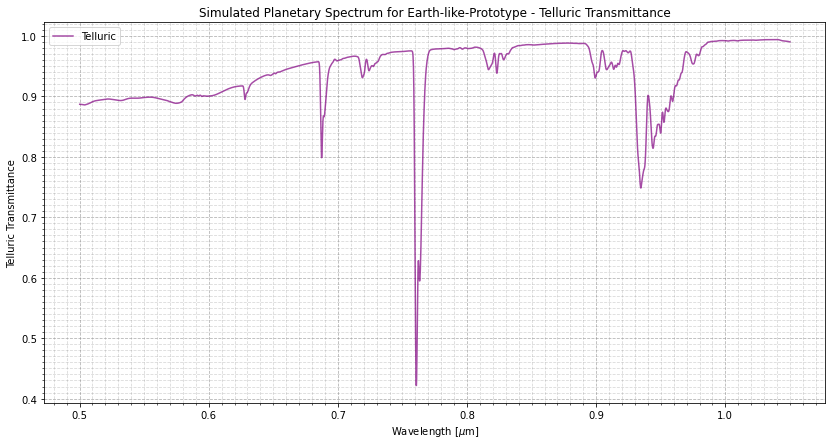

In [4]:
print(df_tel)

plt.figure(figsize=(14, 7))
plt.plot(df_tel['Wave/freq'], df_tel['Telluric'],
         label='Telluric', 
         color='purple', 
         alpha=0.7)


plt.xlabel('Wavelength [$\mu$m]')
#plt.xscale('log')
plt.ylabel('Telluric Transmittance') 
plt.title('Simulated Planetary Spectrum for Earth-like-Prototype - Telluric Transmittance')
plt.legend()

ax = plt.gca() 

ax.xaxis.set_major_locator(MultipleLocator(0.1))
ax.yaxis.set_major_locator(MultipleLocator(0.1))

ax.xaxis.set_minor_locator(MultipleLocator(0.01))
ax.yaxis.set_minor_locator(MultipleLocator(0.01))


plt.grid(visible=True, 
         which='major', 
         color='grey', 
         linestyle='--', 
         alpha=0.6)
plt.grid(visible=True, 
         which='minor', 
         color='grey', 
         linestyle='--', 
         alpha=0.3)

plt.legend()
plt.show()

      Wave/freq  Transmittance
0      0.500100   6.554488e-07
1      0.500200   6.558229e-07
2      0.500300   6.562469e-07
3      0.500400   6.567147e-07
4      0.500500   6.572190e-07
...         ...            ...
3705   1.049148   4.104328e-07
3706   1.049358   4.105852e-07
3707   1.049568   4.107281e-07
3708   1.049778   4.108548e-07
3709   1.049988   4.109608e-07

[3710 rows x 2 columns]


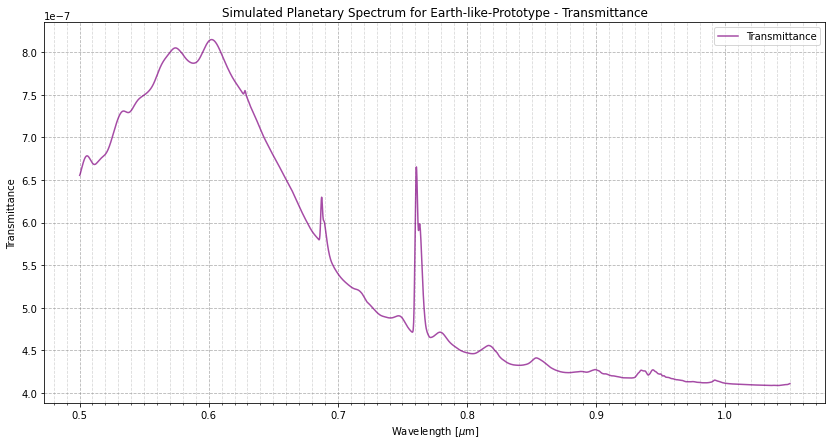

In [5]:
print(df_trn)

plt.figure(figsize=(14, 7))
plt.plot(df_trn['Wave/freq'], df_trn['Transmittance'],
         label='Transmittance', 
         color='purple', 
         alpha=0.7)


plt.xlabel('Wavelength [$\mu$m]')
#plt.xscale('log')
plt.ylabel('Transmittance') 
plt.title('Simulated Planetary Spectrum for Earth-like-Prototype - Transmittance')
plt.legend()

ax = plt.gca() 

ax.xaxis.set_major_locator(MultipleLocator(0.1))
ax.yaxis.set_major_locator(MultipleLocator(0.5e-7))

ax.xaxis.set_minor_locator(MultipleLocator(0.01))
ax.yaxis.set_minor_locator(MultipleLocator(1e-7))


plt.grid(visible=True, 
         which='major', 
         color='grey', 
         linestyle='--', 
         alpha=0.6)
plt.grid(visible=True, 
         which='minor', 
         color='grey', 
         linestyle='--', 
         alpha=0.3)

plt.legend()
plt.show()

# Comparing no atmosphere and carbon dioxide of 40,000ppm which is the upper limit of toxicity for (human)life with standard Earth Prototype

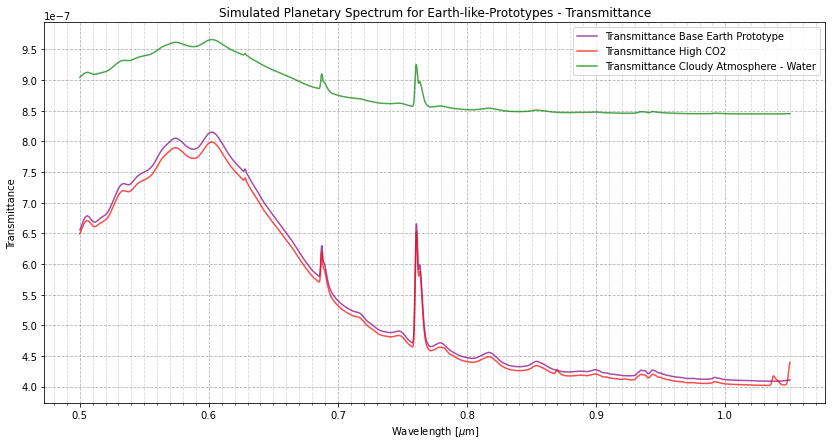

In [6]:
df_co2 = pd.read_csv('psg_trn-40000ppm-CO2.txt', delim_whitespace=True).dropna()
df_cloudy =pd.read_csv('psg_trn-Cloudy-water.txt', delim_whitespace=True).dropna()

plt.figure(figsize=(14, 7))

plt.plot(df_trn['Wave/freq'], df_trn['Transmittance'],
         label='Transmittance Base Earth Prototype', 
         color='purple', 
         alpha=0.7)


plt.plot(df_co2['Wave/freq'], df_co2['Total'],
         label='Transmittance High CO2', 
         color='red', 
         alpha=0.7)

plt.plot(df_cloudy['Wave/freq'], df_cloudy['Total'],
         label='Transmittance Cloudy Atmosphere - Water', 
         color='green', 
         alpha=0.7)

plt.xlabel('Wavelength [$\mu$m]')
#plt.xscale('log')
plt.ylabel('Transmittance') 
plt.title('Simulated Planetary Spectrum for Earth-like-Prototypes - Transmittance')
plt.legend()

ax = plt.gca() 

ax.xaxis.set_major_locator(MultipleLocator(0.1))
ax.yaxis.set_major_locator(MultipleLocator(0.5e-7))

ax.xaxis.set_minor_locator(MultipleLocator(0.01))
ax.yaxis.set_minor_locator(MultipleLocator(1e-7))


plt.grid(visible=True, 
         which='major', 
         color='grey', 
         linestyle='--', 
         alpha=0.6)
plt.grid(visible=True, 
         which='minor', 
         color='grey', 
         linestyle='--', 
         alpha=0.3)

plt.legend()
plt.show()

In [39]:
#For throughput values at 60% in PLATO cameras following the gaussian formula , values in nm nanometers
#thr_val = 0.6 * np.exp(-((thr_wave - 650)**2) / (2 * 200**2)) 

throughput_percent =0.6


thr_trn = np.linspace(df_trn['Wave/freq'].iloc[0], df_trn['Wave/freq'].iloc[-1], 10)
thr_co2 = np.linspace(df_trn['Wave/freq'].iloc[0], df_trn['Wave/freq'].iloc[-1], 10)
thr_cloudy = np.linspace(df_trn['Wave/freq'].iloc[0], df_trn['Wave/freq'].iloc[-1], 10)

thr_val= throughput_percent * np.exp(-((thr_wave - 650)**2) / (2 * 200**2))

     
val_trn = convolve_with_throughput( df_trn['Wave/freq'], df_trn['Transmittance'], thr_trn, thr_val)

val_co2 = convolve_with_throughput(df_co2['Wave/freq'].values, df_co2['Total'].values, thr_co2, thr_val)

val_cloudy = convolve_with_throughput(df_cloudy['Wave/freq'].values, df_cloudy['Total'].values, thr_cloudy, thr_val)

print (val_trn)
print(val_co2)
print(val_cloudy)


5.41776604539598e-07
5.332188862856206e-07
8.799203202415763e-07


In [31]:
print(df_trn['Wave/freq'])
print(thr_wave)


0       0.500100
1       0.500200
2       0.500300
3       0.500400
4       0.500500
          ...   
3705    1.049148
3706    1.049358
3707    1.049568
3708    1.049778
3709    1.049988
Name: Wave/freq, Length: 3710, dtype: float64
[0.5001     0.56119865 0.62229731 0.68339596 0.74449462 0.80559327
 0.86669193 0.92779058 0.98888923 1.04998789]
